In [1]:
from google.colab import files
uploaded = files.upload()

Saving BASE DE DADOS PEDE 2024 - DATATHON.xlsx to BASE DE DADOS PEDE 2024 - DATATHON.xlsx


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

# caminho do arquivo no Colab
arquivo = '/content/BASE DE DADOS PEDE 2024 - DATATHON.xlsx'

# leitura das abas
df_2022 = pd.read_excel(arquivo, sheet_name='PEDE2022')
df_2023 = pd.read_excel(arquivo, sheet_name='PEDE2023')
df_2024 = pd.read_excel(arquivo, sheet_name='PEDE2024')

print(df_2022.shape)
print(df_2023.shape)
print(df_2024.shape)

(860, 42)
(1014, 48)
(1156, 50)


In [3]:
# cópias
d22 = df_2022.copy()
d23 = df_2023.copy()
d24 = df_2024.copy()

# padronização 2022
d22 = d22.rename(columns={
    'Nome': 'Nome_Anonimizado',
    'Idade 22': 'Idade',
    'INDE 22': 'INDE',
    'Matem': 'Mat',
    'Portug': 'Por',
    'Inglês': 'Ing',
    'Fase ideal': 'Fase_Ideal',
    'Defas': 'Defasagem'
})
d22['Ano'] = 2022

# padronização 2023
d23 = d23.rename(columns={
    'Nome Anonimizado': 'Nome_Anonimizado',
    'INDE 2023': 'INDE',
    'Pedra 2023': 'Pedra',
    'Fase Ideal': 'Fase_Ideal'
})
d23['Ano'] = 2023

# padronização 2024
d24 = d24.rename(columns={
    'Nome Anonimizado': 'Nome_Anonimizado',
    'INDE 2024': 'INDE',
    'Pedra 2024': 'Pedra',
    'Fase Ideal': 'Fase_Ideal'
})
d24['Ano'] = 2024

In [4]:
colunas_base = [
    'RA', 'Ano', 'Fase', 'Turma', 'Nome_Anonimizado', 'Idade', 'Gênero',
    'Ano ingresso', 'Instituição de ensino', 'INDE', 'IAA', 'IEG', 'IPS',
    'IPP', 'IDA', 'IPV', 'IAN', 'Fase_Ideal', 'Defasagem',
    'Atingiu PV', 'Pedra', 'Rec Psicologia'
]

# garantir que só pegue colunas existentes em cada aba
d22_base = d22[[c for c in colunas_base if c in d22.columns]].copy()
d23_base = d23[[c for c in colunas_base if c in d23.columns]].copy()
d24_base = d24[[c for c in colunas_base if c in d24.columns]].copy()

# concatenar
df = pd.concat([d22_base, d23_base, d24_base], ignore_index=True)

print(df.shape)
df.head()

(3030, 22)


,RA,Ano,Fase,Turma,Nome_Anonimizado,Idade,Gênero,Ano ingresso,Instituição de ensino,INDE,...,IPS,IDA,IPV,IAN,Fase_Ideal,Defasagem,Atingiu PV,Rec Psicologia,IPP,Pedra
0,RA-1,2022,7,A,Aluno-1,19,Menina,2016,Escola Pública,5.783,...,5.6,4.0,7.278,5.0,Fase 8 (Universitários),-1,Não,Requer avaliação,NaN,NaN
1,RA-2,2022,7,A,Aluno-2,17,Menina,2017,Rede Decisão,7.055,...,6.3,6.8,6.778,10.0,Fase 7 (3º EM),0,Não,Sem limitações,NaN,NaN
2,RA-3,2022,7,A,Aluno-3,17,Menina,2016,Rede Decisão,6.591,...,5.6,5.6,7.556,10.0,Fase 7 (3º EM),0,Não,Sem limitações,NaN,NaN
3,RA-4,2022,7,A,Aluno-4,17,Menino,2017,Rede Decisão,5.951,...,5.6,5.0,5.278,10.0,Fase 7 (3º EM),0,Não,Requer avaliação,NaN,NaN
4,RA-5,2022,7,A,Aluno-5,17,Menina,2016,Rede Decisão,7.427,...,5.6,5.2,7.389,10.0,Fase 7 (3º EM),0,Não,Requer avaliação,NaN,NaN


In [5]:
colunas_numericas = ['INDE', 'IAA', 'IEG', 'IPS', 'IPP', 'IDA', 'IPV', 'IAN', 'Idade', 'Defasagem']

for col in colunas_numericas:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3030 entries, 0 to 3029
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   RA                     3030 non-null   object 
 1   Ano                    3030 non-null   int64  
 2   Fase                   3030 non-null   object 
 3   Turma                  3030 non-null   object 
 4   Nome_Anonimizado       3030 non-null   object 
 5   Idade                  2631 non-null   float64
 6   Gênero                 3030 non-null   object 
 7   Ano ingresso           3030 non-null   int64  
 8   Instituição de ensino  3029 non-null   object 
 9   INDE                   2845 non-null   float64
 10  IAA                    2865 non-null   float64
 11  IEG                    2954 non-null   float64
 12  IPS                    2859 non-null   float64
 13  IDA                    2852 non-null   float64
 14  IPV                    2852 non-null   float64
 15  IAN 

In [6]:
df.describe(include='all')

,RA,Ano,Fase,Turma,Nome_Anonimizado,Idade,Gênero,Ano ingresso,Instituição de ensino,INDE,...,IPS,IDA,IPV,IAN,Fase_Ideal,Defasagem,Atingiu PV,Rec Psicologia,IPP,Pedra
count,3030,3030.00000,3030,3030,3030,2631.000000,3030,3030.000000,3029,2845.000000,...,2859.000000,2852.000000,2852.000000,3030.000000,3030,3030.000000,860,860,1992.000000,2023
unique,1661,NaN,88,120,1661,NaN,4,NaN,12,NaN,...,NaN,NaN,NaN,NaN,17,NaN,2,5,NaN,5
top,RA-860,NaN,ALFA,A,Aluno-860,NaN,Feminino,NaN,Pública,NaN,...,NaN,NaN,NaN,NaN,Fase 2 (5° e 6° ano),NaN,Não,Não atendido,NaN,Ametista
freq,3,NaN,427,107,3,NaN,1169,NaN,1722,NaN,...,NaN,NaN,NaN,NaN,527,NaN,747,406,NaN,772
mean,NaN,2023.09769,NaN,NaN,NaN,12.548081,NaN,2021.563696,NaN,7.269915,...,6.287129,6.375964,7.545476,7.179043,NaN,-0.642904,NaN,NaN,7.555203,NaN
std,NaN,0.80995,NaN,NaN,NaN,3.283307,NaN,1.822171,NaN,0.991767,...,1.792491,1.956637,1.084347,2.535266,NaN,0.866382,NaN,NaN,0.938990,NaN
min,NaN,2022.00000,NaN,NaN,NaN,7.000000,NaN,2016.000000,NaN,3.032000,...,2.500000,0.000000,2.500000,2.500000,NaN,-5.000000,NaN,NaN,2.500000,NaN
25%,NaN,2022.00000,NaN,NaN,NaN,10.000000,NaN,2021.000000,NaN,6.675200,...,5.020000,5.100000,6.984000,5.000000,NaN,-1.000000,NaN,NaN,7.083333,NaN
50%,NaN,2023.00000,NaN,NaN,NaN,12.000000,NaN,2022.000000,NaN,7.388267,...,7.500000,6.666667,7.583000,5.000000,NaN,-1.000000,NaN,NaN,7.500000,NaN
75%,NaN,2024.00000,NaN,NaN,NaN,15.000000,NaN,2023.000000,NaN,7.986867,...,7.510000,7.833333,8.255000,10.000000,NaN,0.000000,NaN,NaN,8.125000,NaN


In [7]:
percent_null = (df.isna().mean() * 100).sort_values(ascending=False)
percent_null[percent_null > 0]

,0
Rec Psicologia,71.617162
Atingiu PV,71.617162
IPP,34.257426
Pedra,33.234323
Idade,13.168317
INDE,6.105611
IPV,5.874587
IDA,5.874587
IPS,5.643564
IAA,5.445545


In [8]:
## 1. Adequação do nível (IAN): Qual é o perfil geral de defasagem dos alunos (IAN) e como ele evolui ao longo do ano?(Ex.: quantos alunos estão moderadamente ou severamente defasados?)

In [9]:
import numpy as np
import pandas as pd
import plotly.express as px

def classificar_ian(valor):
    if pd.isna(valor):
        return np.nan
    elif valor <= 4:
        return 'Severamente defasado'
    elif valor <= 6:
        return 'Moderadamente defasado'
    elif valor < 10:
        return 'Levemente defasado'
    else:
        return 'Adequado'

df['Faixa_IAN'] = df['IAN'].apply(classificar_ian)

ian_resumo = (
    df.groupby(['Ano', 'Faixa_IAN'])
      .size()
      .reset_index(name='Qtd_Alunos')
)

# total de alunos por ano
total_ano = (
    ian_resumo.groupby('Ano')['Qtd_Alunos']
    .sum()
    .reset_index(name='Total_Ano')
)

# junta e calcula percentual
ian_resumo = ian_resumo.merge(total_ano, on='Ano', how='left')
ian_resumo['Perc_Alunos'] = (ian_resumo['Qtd_Alunos'] / ian_resumo['Total_Ano']) * 100

# ordem das categorias
ordem_faixas = [
    'Severamente defasado',
    'Moderadamente defasado',
    'Levemente defasado',
    'Adequado'
]

ian_resumo['Faixa_IAN'] = pd.Categorical(
    ian_resumo['Faixa_IAN'],
    categories=ordem_faixas,
    ordered=True
)

ian_resumo = ian_resumo.sort_values(['Ano', 'Faixa_IAN'])

ian_resumo

,Ano,Faixa_IAN,Qtd_Alunos,Total_Ano,Perc_Alunos
2,2022,Severamente defasado,28,860,3.255814
1,2022,Moderadamente defasado,573,860,66.627907
0,2022,Adequado,259,860,30.116279
5,2023,Severamente defasado,14,1014,1.380671
4,2023,Moderadamente defasado,538,1014,53.057199
3,2023,Adequado,462,1014,45.562130
8,2024,Severamente defasado,3,1156,0.259516
7,2024,Moderadamente defasado,531,1156,45.934256
6,2024,Adequado,622,1156,53.806228


In [10]:
fig = px.bar(
    ian_resumo,
    x='Ano',
    y='Perc_Alunos',
    color='Faixa_IAN',
    barmode='stack',
    text='Perc_Alunos',
    title='Distribuição percentual dos alunos por faixa de IAN ao longo dos anos',
    category_orders={'Faixa_IAN': ordem_faixas}
)

fig.update_traces(texttemplate='%{text:.1f}%', textposition='inside')
fig.update_layout(
    yaxis_title='Percentual de alunos',
    xaxis_title='Ano'
)



fig.show()


In [11]:
## 2. Desempenho acadêmico (IDA): O desempenho acadêmico médio (IDA) está melhorando, estagnado ou caindo ao longo das fases e anos?

In [12]:
ida_ano = df.groupby('Ano', as_index=False)['IDA'].mean()

import plotly.express as px

fig = px.bar(
    ida_ano,
    x='Ano',
    y='IDA',
    text='IDA',
    title='Média de IDA por ano'
)

fig.update_traces(texttemplate='%{text:.2f}', textposition='outside')
fig.update_layout(
    title='Média de IDA por ano',
    xaxis_title='Ano',
    yaxis_title='IDA'
)



In [13]:
df_2024 = df[df['Ano'] == 2024].copy()

df_2024['IDA'] = pd.to_numeric(df_2024['IDA'], errors='coerce')
df_2024['Fase_Grupo'] = df_2024['Fase'].astype(str).str.extract(r'(\d+)')

ida_2024 = (
    df_2024.groupby('Fase_Grupo', as_index=False)['IDA']
    .mean()
    .dropna()
)

ida_2024['Fase_Grupo'] = ida_2024['Fase_Grupo'].astype(int)

fig = px.line(
    ida_2024.sort_values('Fase_Grupo'),
    x='Fase_Grupo',
    y='IDA',
    markers=True,
    title='IDA por grupo de fase - 2024'
)

fig.show()

In [14]:
df_2022 = df[df['Ano'] == 2022].copy()

ida_2022 = df_2022.groupby('Fase', as_index=False)['IDA'].mean()

fig = px.line(
    ida_2022.sort_values('Fase'),
    x='Fase',
    y='IDA',
    markers=True,
    title='IDA por fase - 2022'
)

fig.show()

In [15]:
df_2023 = df[df['Ano'] == 2023].copy()

df_2023['IDA'] = pd.to_numeric(df_2023['IDA'], errors='coerce')

ida_2023 = df_2023.groupby('Fase', as_index=False)['IDA'].mean()

# extrair número da fase (quando existir)
ida_2023['Ordem'] = ida_2023['Fase'].str.extract(r'(\d+)')

# converter para número
ida_2023['Ordem'] = pd.to_numeric(ida_2023['Ordem'], errors='coerce')

# tratar ALFA (colocar como fase 0)
ida_2023.loc[ida_2023['Fase'].str.contains('ALFA', case=False, na=False), 'Ordem'] = 0

# ordenar corretamente
ida_2023 = ida_2023.sort_values('Ordem')

import plotly.express as px

fig = px.line(
    ida_2023,
    x='Fase',
    y='IDA',
    markers=True,
    title='IDA por fase - 2023'
)

fig.show()

In [16]:
## 3. Engajamento nas atividades (IEG): O grau de engajamento dos alunos (IEG) tem relação direta com seus indicadores de desempenho (IDA) e do ponto de virada (IPV)?

In [17]:
correlacoes = df[['IEG', 'IDA', 'IPV']].corr()
correlacoes

,IEG,IDA,IPV
IEG,1.000000,0.539057,0.558200
IDA,0.539057,1.000000,0.557072
IPV,0.558200,0.557072,1.000000


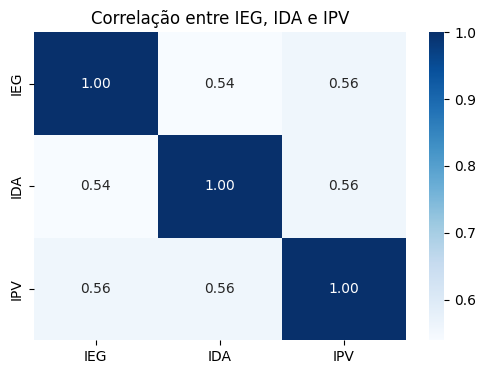

In [18]:
plt.figure(figsize=(6,4))
sns.heatmap(correlacoes, annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlação entre IEG, IDA e IPV')
plt.show()

In [19]:
fig = px.scatter(
    df,
    x='IEG',
    y='IDA',
    color='Ano',
    trendline='ols',
    title='Relação entre engajamento (IEG) e desempenho acadêmico (IDA)'
)
fig.show()

In [20]:
## 4. Autoavaliação (IAA): As percepções dos alunos sobre si mesmos (IAA) são coerentes com seu desempenho real (IDA) e engajamento (IEG)?

In [21]:
df['Gap_Autoavaliacao'] = df['IAA'] - df['IDA']

gap_resumo = df['Gap_Autoavaliacao'].describe()
gap_resumo

,Gap_Autoavaliacao
count,2851.000000
mean,1.552776
std,3.080380
min,-9.900000
25%,0.400000
50%,1.800000
75%,3.400000
max,9.600000


In [22]:
fig = px.histogram(
    df,
    x='Gap_Autoavaliacao',
    nbins=30,
    title='Diferença entre autoavaliação (IAA) e desempenho real (IDA)'
)
fig.show()

In [23]:
import plotly.express as px

df_plot = df.copy()

df_plot['IAA'] = pd.to_numeric(df_plot['IAA'], errors='coerce')
df_plot['IDA'] = pd.to_numeric(df_plot['IDA'], errors='coerce')

df_plot = df_plot.dropna(subset=['IAA', 'IDA'])

fig = px.scatter(
    df_plot,
    x='IAA',
    y='IDA',
    color='Ano',
    title='Relação entre Autoavaliação (IAA) e Desempenho (IDA)',
    trendline='ols'
)

fig.update_traces(marker=dict(size=5, opacity=0.5))

fig.show()

In [24]:
## 5. Aspectos psicossociais (IPS): Há padrões psicossociais (IPS) que antecedem quedas de desempenho acadêmico ou de engajamento?

In [25]:
df_modelo_tempo = df.sort_values(['RA', 'Ano']).copy()

df_modelo_tempo['IDA_ano_seguinte'] = df_modelo_tempo.groupby('RA')['IDA'].shift(-1)
df_modelo_tempo['IEG_ano_seguinte'] = df_modelo_tempo.groupby('RA')['IEG'].shift(-1)

df_modelo_tempo['Queda_IDA'] = (df_modelo_tempo['IDA_ano_seguinte'] < df_modelo_tempo['IDA']).astype(float)
df_modelo_tempo['Queda_IEG'] = (df_modelo_tempo['IEG_ano_seguinte'] < df_modelo_tempo['IEG']).astype(float)

df_modelo_tempo[['RA', 'Ano', 'IPS', 'IDA', 'IDA_ano_seguinte', 'Queda_IDA']].head(10)

,RA,Ano,IPS,IDA,IDA_ano_seguinte,Queda_IDA
0,RA-1,2022,5.60,4.00,NaN,0.0
1855,RA-1,2023,NaN,NaN,NaN,0.0
2958,RA-1,2024,NaN,NaN,NaN,0.0
9,RA-10,2022,5.00,4.10,NaN,0.0
99,RA-100,2022,5.00,7.60,NaN,0.0
1072,RA-1000,2023,3.77,7.00,7.75,0.0
2225,RA-1000,2024,6.26,7.75,NaN,0.0
1074,RA-1001,2023,7.52,7.80,7.75,1.0
2227,RA-1001,2024,7.51,7.75,NaN,0.0
1075,RA-1002,2023,7.52,7.00,9.25,0.0


In [26]:
df_modelo_tempo.groupby('Queda_IDA')['IPS'].mean()
df_modelo_tempo.groupby('Queda_IEG')['IPS'].mean()

,IPS
Queda_IEG,
0.0,6.468622
1.0,5.702171


In [27]:
## 6. Aspectos psicopedagógicos (IPP): As avaliações psicopedagógicas (IPP) confirmam ou contradizem a defasagem identificada pelo IAN?

In [28]:
df[['IPP', 'IAN']].corr()

,IPP,IAN
IPP,1.000000,0.123398
IAN,0.123398,1.000000


In [29]:
fig = px.scatter(
    df,
    x='IAN',
    y='IPP',
    color='Ano',
    title='Relação entre IAN e IPP'
)
fig.show()

In [30]:
import plotly.express as px

df_plot = df.copy()

df_plot['IPP'] = pd.to_numeric(df_plot['IPP'], errors='coerce')
df_plot = df_plot.dropna(subset=['IPP', 'Faixa_IAN'])

ordem = [
    'Severamente defasado',
    'Moderadamente defasado',
    'Levemente defasado',
    'Adequado'
]

df_plot['Faixa_IAN'] = pd.Categorical(
    df_plot['Faixa_IAN'],
    categories=ordem,
    ordered=True
)

fig = px.box(
    df_plot,
    x='Faixa_IAN',
    y='IPP',
    title='Desenvolvimento (IPP) por nível de adequação (IAN)'
)

ordem = [
    'Severamente defasado',
    'Moderadamente defasado',
    'Levemente defasado',
    'Adequado'
]

df_plot['Faixa_IAN'] = pd.Categorical(
    df_plot['Faixa_IAN'],
    categories=ordem,
    ordered=True
)

fig.show()


In [31]:
## 7. Ponto de virada (IPV): Quais comportamentos - acadêmicos, emocionais ou de engajamento - mais influenciam o IPV ao longo do tempo?

In [32]:
df[['IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IAN', 'IPV']].corr()['IPV'].sort_values(ascending=False)

,IPV
IPV,1.000000
IPP,0.606649
IEG,0.558200
IDA,0.557072
IAN,0.148880
IAA,0.062728
IPS,-0.048750


In [33]:
df_ml = df.copy()

df_ml['Risco_Defasagem'] = np.where(
    ((df_ml['IAN'] <= 6) | (df_ml['Defasagem'] < 0)),
    1, 0
)

df_ml['Risco_Defasagem'].value_counts(normalize=True)

,proportion
Risco_Defasagem,
1,0.556766
0,0.443234


In [34]:
## 8. Multidimensionalidade dos indicadores: Quais combinações de indicadores (IDA + IEG + IPS + IPP) elevam mais a nota global do aluno (INDE)?

In [35]:
df[['INDE', 'IDA', 'IEG', 'IPS', 'IPP']].corr()['INDE'].sort_values(ascending=False)

,INDE
INDE,1.000000
IDA,0.785311
IEG,0.745330
IPP,0.540295
IPS,0.199618


In [36]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.ensemble import RandomForestClassifier

features = ['Fase', 'Idade', 'Gênero', 'Instituição de ensino', 'IAA', 'IEG', 'IPS', 'IPP', 'IDA', 'IPV', 'INDE']
target = 'Risco_Defasagem'

base_modelo = df_ml[features + [target]].copy()

# garante que o target está numérico
base_modelo[target] = pd.to_numeric(base_modelo[target], errors='coerce')

# remove linhas sem target
base_modelo = base_modelo.dropna(subset=[target])

X = base_modelo[features].copy()
y = base_modelo[target].astype(int)

# define colunas numéricas e categóricas manualmente
num_cols = ['Idade', 'IAA', 'IEG', 'IPS', 'IPP', 'IDA', 'IPV', 'INDE']
cat_cols = ['Fase', 'Gênero', 'Instituição de ensino']

# força numéricas para número
for col in num_cols:
    X[col] = pd.to_numeric(X[col], errors='coerce')

# força categóricas para texto
for col in cat_cols:
    X[col] = X[col].astype(str)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median'))
        ]), num_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_cols)
    ]
)

model = Pipeline(steps=[
    ('prep', preprocessor),
    ('clf', RandomForestClassifier(random_state=42, n_estimators=200))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print('ROC AUC:', roc_auc_score(y_test, y_prob))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.82      0.86       269
           1       0.87      0.93      0.90       337

    accuracy                           0.88       606
   macro avg       0.88      0.87      0.88       606
weighted avg       0.88      0.88      0.88       606

ROC AUC: 0.9518934839442711
[[221  48]
 [ 25 312]]


In [37]:
## 9. Previsão de risco com Machine Learning: Quais padrões nos indicadores permitem identificar alunos em risco antes de queda no desempenho ou aumento da defasagem? Construa um modelo preditivo que mostre uma probabilidade do aluno ou aluna entrar em risco de defasagem.

In [38]:
ohe = model.named_steps['prep'].named_transformers_['cat'].named_steps['onehot']
cat_feature_names = ohe.get_feature_names_out(cat_cols)

feature_names = num_cols + list(cat_feature_names)
importancias = model.named_steps['clf'].feature_importances_

imp_df = pd.DataFrame({
    'Variavel': feature_names,
    'Importancia': importancias
}).sort_values('Importancia', ascending=False).head(15)

imp_df

,Variavel,Importancia
7,INDE,0.196276
0,Idade,0.136277
5,IDA,0.088897
6,IPV,0.085673
2,IEG,0.085025
1,IAA,0.056940
3,IPS,0.047728
4,IPP,0.045946
103,Instituição de ensino_Escola Pública,0.017742
108,Instituição de ensino_Privada - Programa de Ap...,0.012866


In [39]:
fig = px.bar(
    imp_df.sort_values('Importancia'),
    x='Importancia',
    y='Variavel',
    orientation='h',
    title='Top variáveis mais importantes para prever risco de defasagem'
)
fig.show()

In [40]:
## 10. Efetividade do programa: Os indicadores mostram melhora consistente ao longo do ciclo nas diferentes fases (Quartzo, Ágata, Ametista e Topázio), confirmando o impacto real do programa?

In [41]:
## Análise ao longo do tempo (geral)

In [42]:
evolucao_geral = df.groupby('Ano')[['INDE', 'IDA', 'IEG', 'IPV']].mean().reset_index()

evolucao_geral

,Ano,INDE,IDA,IEG,IPV
0,2022,7.036176,6.092907,7.891163,7.253642
1,2023,7.342309,6.663394,8.699041,8.027897
2,2024,7.396686,6.351422,7.374988,7.354268


In [43]:
import plotly.express as px

fig = px.line(
    evolucao_geral.melt(id_vars='Ano'),
    x='Ano',
    y='value',
    color='variable',
    markers=True,
    title='Evolução dos principais indicadores ao longo dos anos'
)

fig.show()

In [44]:
inde_ano = df.groupby('Ano', as_index=False)['INDE'].mean()

fig = px.bar(
    inde_ano,
    x='Ano',
    y='INDE',
    title='Evolução do índice geral (INDE)',
    text_auto='.2f'
)

fig.show()

In [45]:
evolucao_fase = df.groupby(['Ano', 'Fase'])[['INDE', 'IDA', 'IEG']].mean().reset_index()

evolucao_fase.head()

,Ano,Fase,INDE,IDA,IEG
0,2022,0,7.365553,7.140000,8.088947
1,2022,1,7.199828,6.464062,8.522396
2,2022,2,6.958929,5.406452,8.165806
3,2022,3,6.599865,5.141892,7.068243
4,2022,4,7.005276,6.052632,7.660526


In [46]:
## Evolução por fase

In [47]:
fig = px.line(
    evolucao_fase,
    x='Fase',
    y='INDE',
    color='Ano',
    markers=True,
    title='Evolução do INDE por fase ao longo dos anos'
)

fig.show()

In [48]:
## Progressão dos alunos ao longo do tempo (visão longitudinal

In [49]:
df_sorted = df.sort_values(['RA', 'Ano'])

df_sorted['INDE_ano_anterior'] = df_sorted.groupby('RA')['INDE'].shift(1)

df_sorted['Evolucao_INDE'] = df_sorted['INDE'] - df_sorted['INDE_ano_anterior']

df_sorted[['RA', 'Ano', 'INDE', 'INDE_ano_anterior', 'Evolucao_INDE']].head()

,RA,Ano,INDE,INDE_ano_anterior,Evolucao_INDE
0,RA-1,2022,5.783,NaN,NaN
1855,RA-1,2023,NaN,5.783,NaN
2958,RA-1,2024,NaN,NaN,NaN
9,RA-10,2022,5.784,NaN,NaN
99,RA-100,2022,7.618,NaN,NaN


In [50]:
df_sorted.groupby('Ano')['Evolucao_INDE'].mean()

,Evolucao_INDE
Ano,
2022,NaN
2023,-0.024755
2024,-0.043845


In [51]:
## Taxa de alunos que melhoram

In [52]:
df_sorted['Melhorou'] = df_sorted['Evolucao_INDE'] > 0

taxa_melhora = df_sorted.groupby('Ano')['Melhorou'].mean()

taxa_melhora

,Melhorou
Ano,
2022,0.000000
2023,0.277120
2024,0.298443


In [53]:
import plotly.express as px

df_plot = df.copy()

df_plot['IPS'] = pd.to_numeric(df_plot['IPS'], errors='coerce')
df_plot['IDA'] = pd.to_numeric(df_plot['IDA'], errors='coerce')

df_plot = df_plot.dropna(subset=['IPS', 'IDA'])

# Criar faixas de IPS
df_plot['Faixa_IPS'] = pd.qcut(df_plot['IPS'], 4, labels=['Baixo', 'Médio-baixo', 'Médio-alto', 'Alto'])

fig = px.box(
    df_plot,
    x='Faixa_IPS',
    y='IDA',
    title='Desempenho (IDA) por nível de IPS'
)


ordem = ['Baixo', 'Médio-baixo', 'Médio-alto', 'Alto']

df_plot['Faixa_IPS'] = pd.Categorical(
    df_plot['Faixa_IPS'],
    categories=ordem,
    ordered=True
)
fig.show()

In [54]:
 ordem = ['Baixo', 'Médio-baixo', 'Médio-alto', 'Alto']

df_plot['Faixa_IPS'] = pd.Categorical(
    df_plot['Faixa_IPS'],
    categories=ordem,
    ordered=True
)